170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4674 - loss: 1.4774 - val_accuracy: 0.5660 - val_loss: 1.2275
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6052 - loss: 1.1243 - val_accuracy: 0.6296 - val_loss: 1.0595
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6567 - loss: 0.9898 - val_accuracy: 0.6514 - val_loss: 1.0192
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6891 - loss: 0.9030 - val_accuracy: 0.6872 - val_loss: 0.9221
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7127 - loss: 0.8314 - val_accuracy: 0.6736 - val_loss: 0.9591


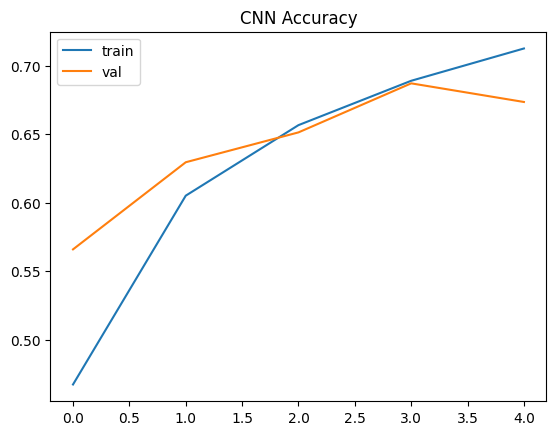

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6736 - loss: 0.9591
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


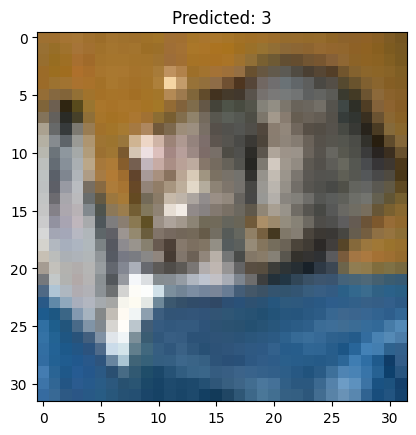

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
a
# Load Data
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize
x_train, x_test = x_train/255.0, x_test/255.0

# Model (CNN)
model = keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test,y_test))

# Graph 📊
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("CNN Accuracy")
plt.legend()
plt.show()

# Evaluate
model.evaluate(x_test, y_test)

# Prediction
pred = model.predict(x_test)
plt.imshow(x_test[0])
plt.title("Predicted: " + str(np.argmax(pred[0])))
plt.show()